## 1. Read the Dataset

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Advertising.csv')

print("Shape:")
print(df.shape)

print("Head:")
print(df.head())


Shape:
(200, 5)
Head:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [2]:

print("Info:")
df.info()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [3]:

print("Description:")
print(df.describe().T)

print("Columns:")
cols = df.columns
print(cols)

Description:
            count      mean        std  min     25%     50%      75%    max
Unnamed: 0  200.0  100.5000  57.879185  1.0  50.750  100.50  150.250  200.0
TV          200.0  147.0425  85.854236  0.7  74.375  149.75  218.825  296.4
Radio       200.0   23.2640  14.846809  0.0   9.975   22.90   36.525   49.6
Newspaper   200.0   30.5540  21.778621  0.3  12.750   25.75   45.100  114.0
Sales       200.0   14.0225   5.217457  1.6  10.375   12.90   17.400   27.0
Columns:
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')


In [4]:

df.drop('Unnamed: 0', axis=1, inplace=True)

print("Head after drop:")
print(df.head())

Head after drop:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [5]:
print("Missing values:")
print(df.isna().sum())

print("Duplicates:")
print(df.duplicated().sum())

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Duplicates:
0


## 2. Exploratory Data Analysis (EDA)

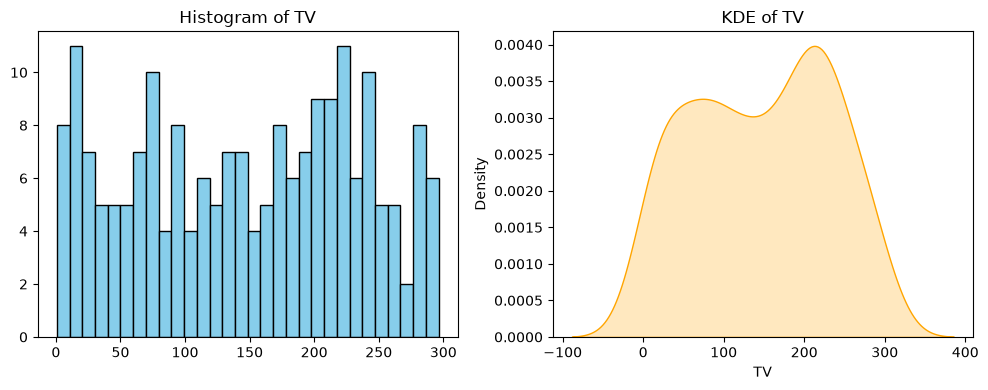

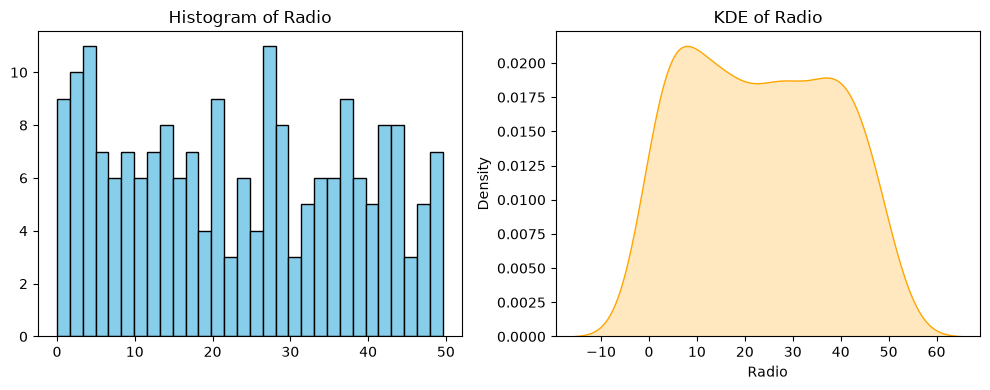

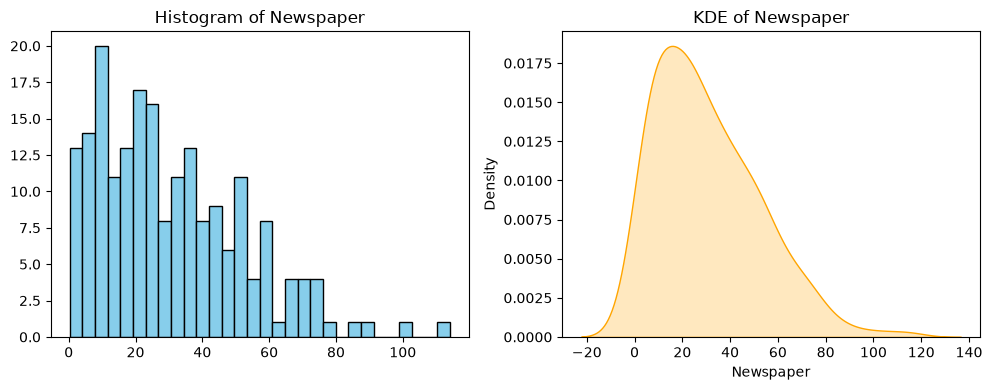

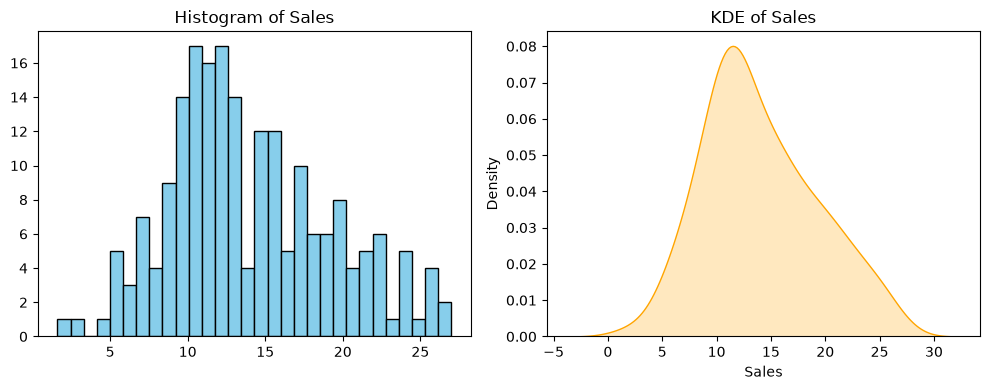

In [6]:
# ### Analysis Columns
# #### Histogram + KDE

# Import matplotlib and seaborn for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

for i in cols[1:]:
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    plt.hist(df[i], bins=30, color='skyblue' , edgecolor='black')
    plt.title(f'Histogram of {i}')

    plt.subplot(1, 2, 2)
    sns.kdeplot(df[i], color='orange' , fill=True)
    plt.title(f'KDE of {i}')

    plt.tight_layout()
    plt.show()

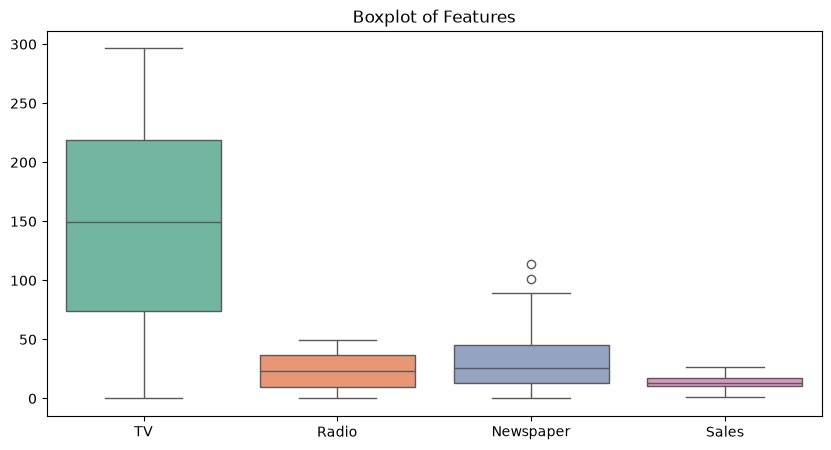

In [7]:
# #### Boxplots (outliers detection)

# Import seaborn and matplotlib for boxplots
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots (outliers detection)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, palette="Set2")
plt.title("Boxplot of Features")
plt.show()

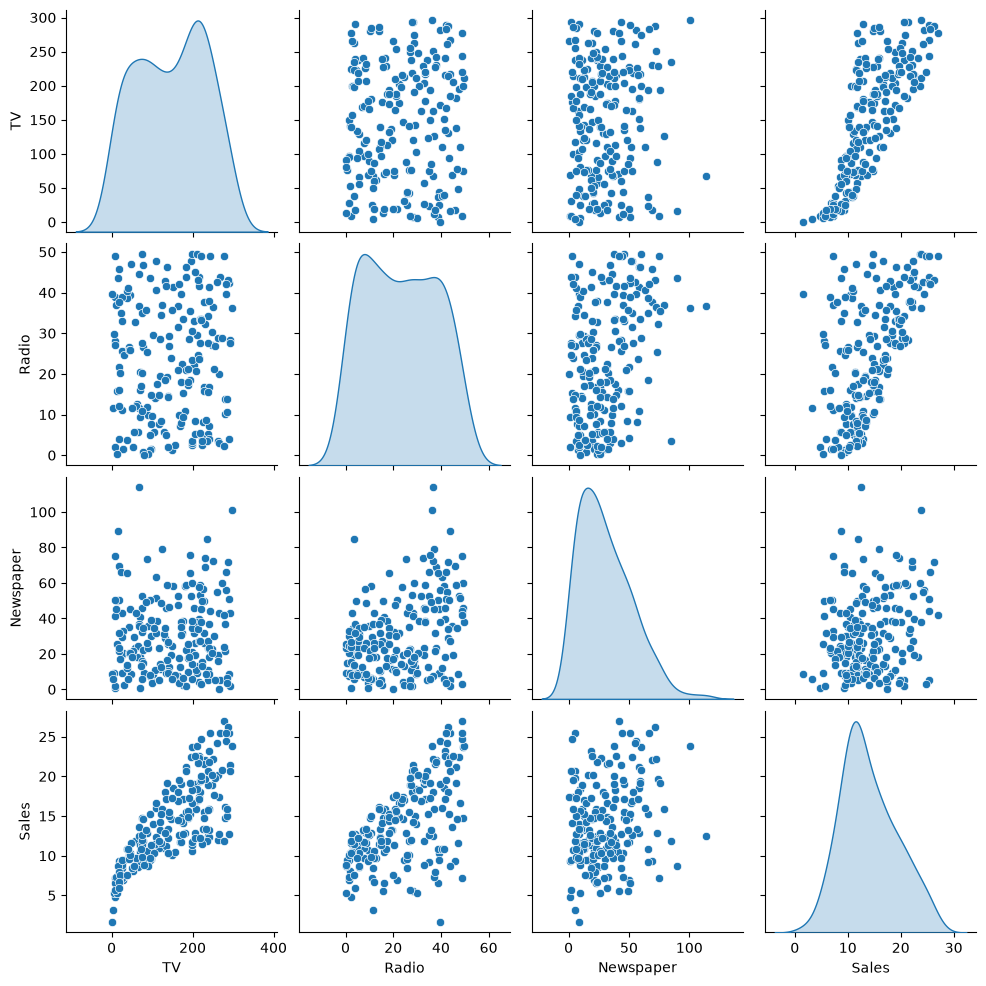

In [8]:
# #### Pairplot

# Import seaborn and matplotlib for the pairplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, diag_kind='kde')
plt.show()

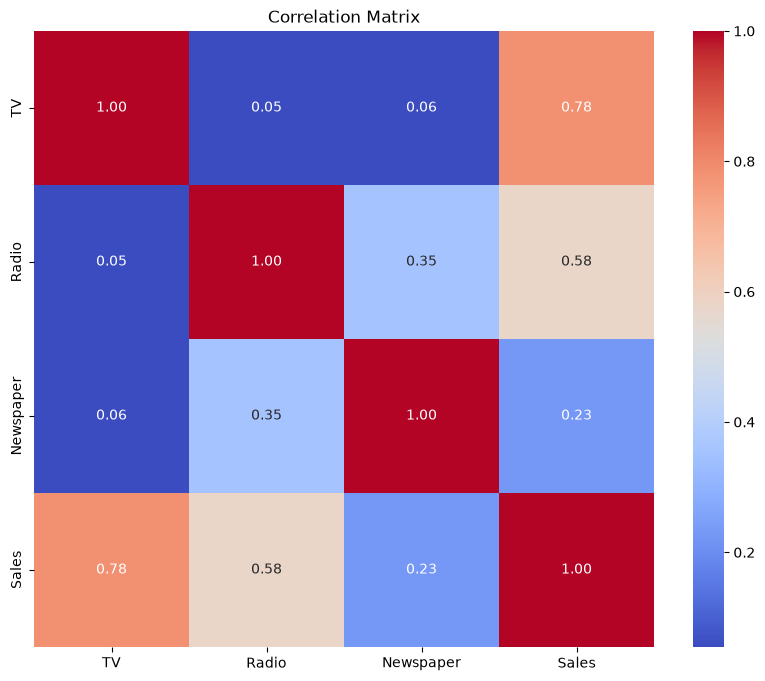

In [9]:
# #### Correlation Matrix

# Import seaborn for the heatmap
import seaborn as sns

corr = df[cols[1:]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

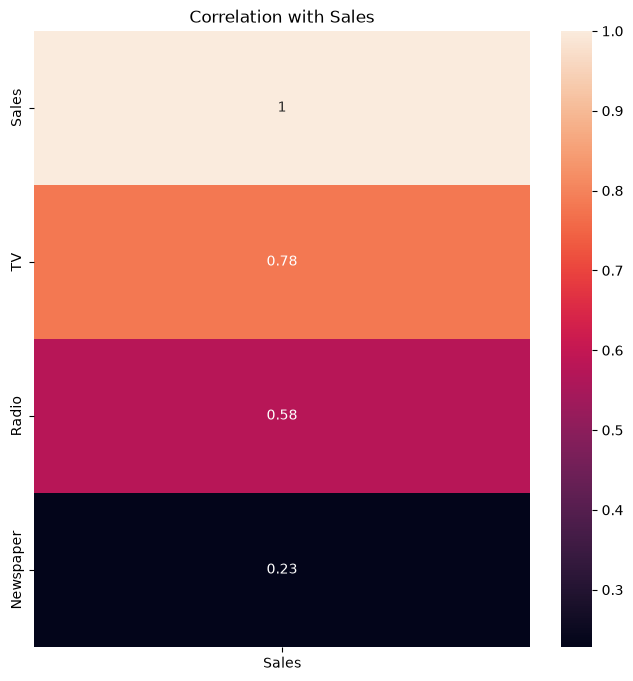

In [10]:

# #### Correlation with Sales

# Import matplotlib and seaborn for the heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))
sns.heatmap(corr[['Sales']].sort_values(by='Sales', ascending=False), annot=True)
plt.title("Correlation with Sales")
plt.show()

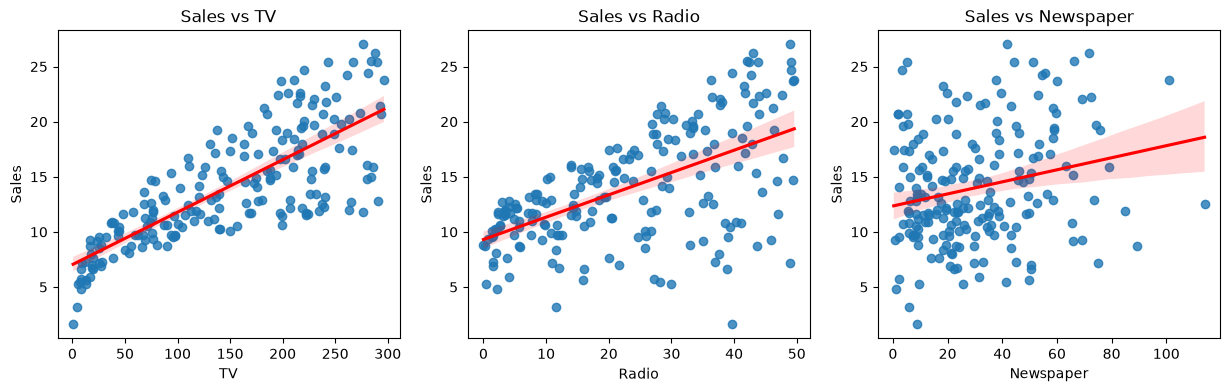

In [11]:
# #### Check Relations

# Import seaborn and matplotlib for the regplots
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

for i, col in enumerate(["TV", "Radio", "Newspaper"]):
    plt.subplot(1, 3, i + 1)
    sns.regplot(data=df, x=col, y="Sales", line_kws={'color':'red'})
    plt.title(f"Sales vs {col}")
    plt.xlabel(col)
    plt.ylabel("Sales")

## 3. Feature Engineering

In [12]:
df["TV_Radio"] = df["TV"] * df["Radio"]

df.head()

,TV,Radio,Newspaper,Sales,TV_Radio
0,230.1,37.8,69.2,22.1,8697.78
1,44.5,39.3,45.1,10.4,1748.85
2,17.2,45.9,69.3,9.3,789.48
3,151.5,41.3,58.5,18.5,6256.95
4,180.8,10.8,58.4,12.9,1952.64


## 4. Split Data into Features and Target

In [13]:
X = df.drop(columns=['Sales'])
y = df['Sales']

X.head()

,TV,Radio,Newspaper,TV_Radio
0,230.1,37.8,69.2,8697.78
1,44.5,39.3,45.1,1748.85
2,17.2,45.9,69.3,789.48
3,151.5,41.3,58.5,6256.95
4,180.8,10.8,58.4,1952.64


## 5. Split Data into Train and Test Sets

In [14]:

# Import train_test_split to split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()

,TV,Radio,Newspaper,TV_Radio
79,116.0,7.7,23.1,893.20
197,177.0,9.3,6.4,1646.10
38,43.1,26.7,35.1,1150.77
24,62.3,12.6,18.3,784.98
122,224.0,2.4,15.6,537.60


## 6. Modeling

### Linear Regression

Linear Regression - Model Performance:
Mean Absolute Error (MAE): 0.67
Root Mean Squared Error (RMSE): 0.90
R² Score: 0.97
Coefficient [0.01961507 0.03397467 0.00190677 0.00104987]


Text(0.5, 1.0, 'Comparison of actual and predicted sales')

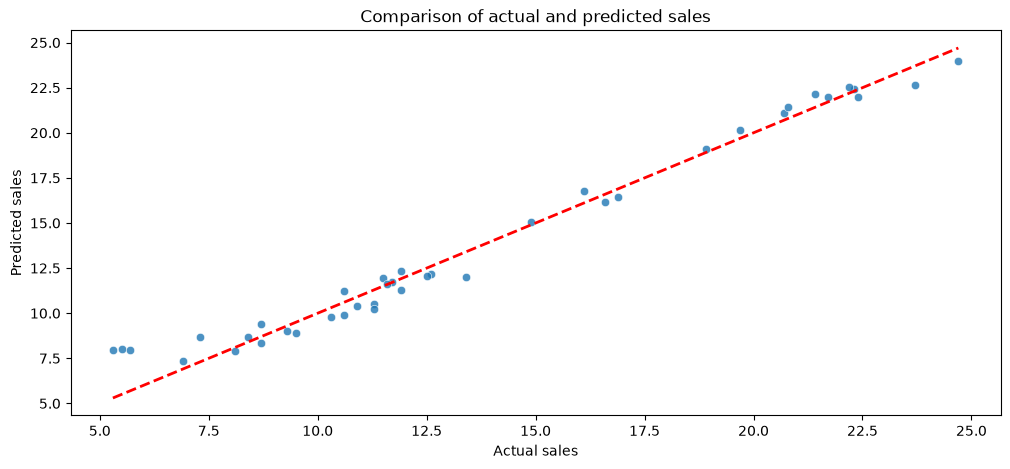

In [15]:
# ### Linear Regression

# Import LinearRegression for the model
from sklearn.linear_model import LinearRegression
import numpy as np
# Import evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_linear = model.predict(X_test)

results = {}

mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression - Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

results['Linear Regression'] = {"MAE": mae, "RMSE": rmse, "R²": r2}

print("Coefficient", model.coef_)

# Import matplotlib and seaborn for the plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.8)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Comparison of actual and predicted sales")

### Decision Tree

In [16]:
# ### Decision Tree

# Import DecisionTreeRegressor and plot_tree
from sklearn.tree import DecisionTreeRegressor, plot_tree

model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10)
model.fit(X_train, y_train)

y_pred_tree = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree - Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

results['Decision Tree'] = {"MAE": mae, "RMSE": rmse, "R²": r2}




Decision Tree - Model Performance:
Mean Absolute Error (MAE): 0.96
Root Mean Squared Error (RMSE): 1.21
R² Score: 0.95


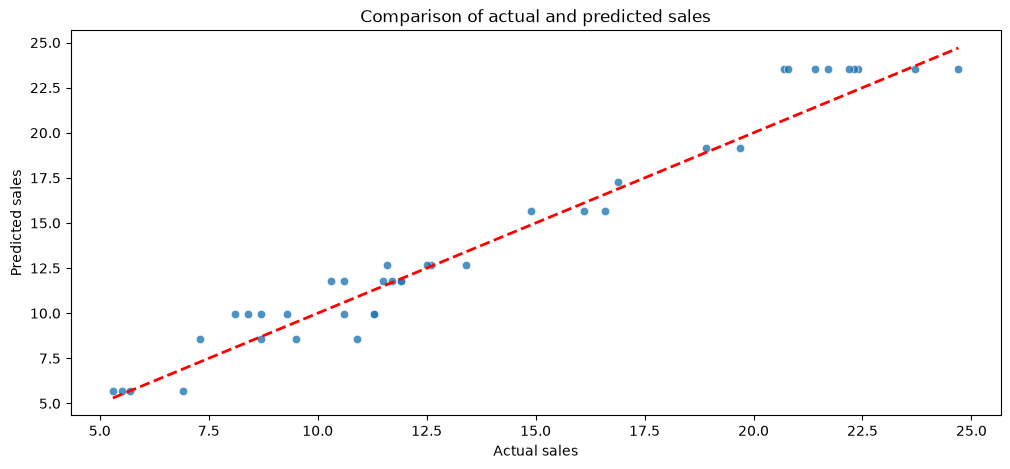

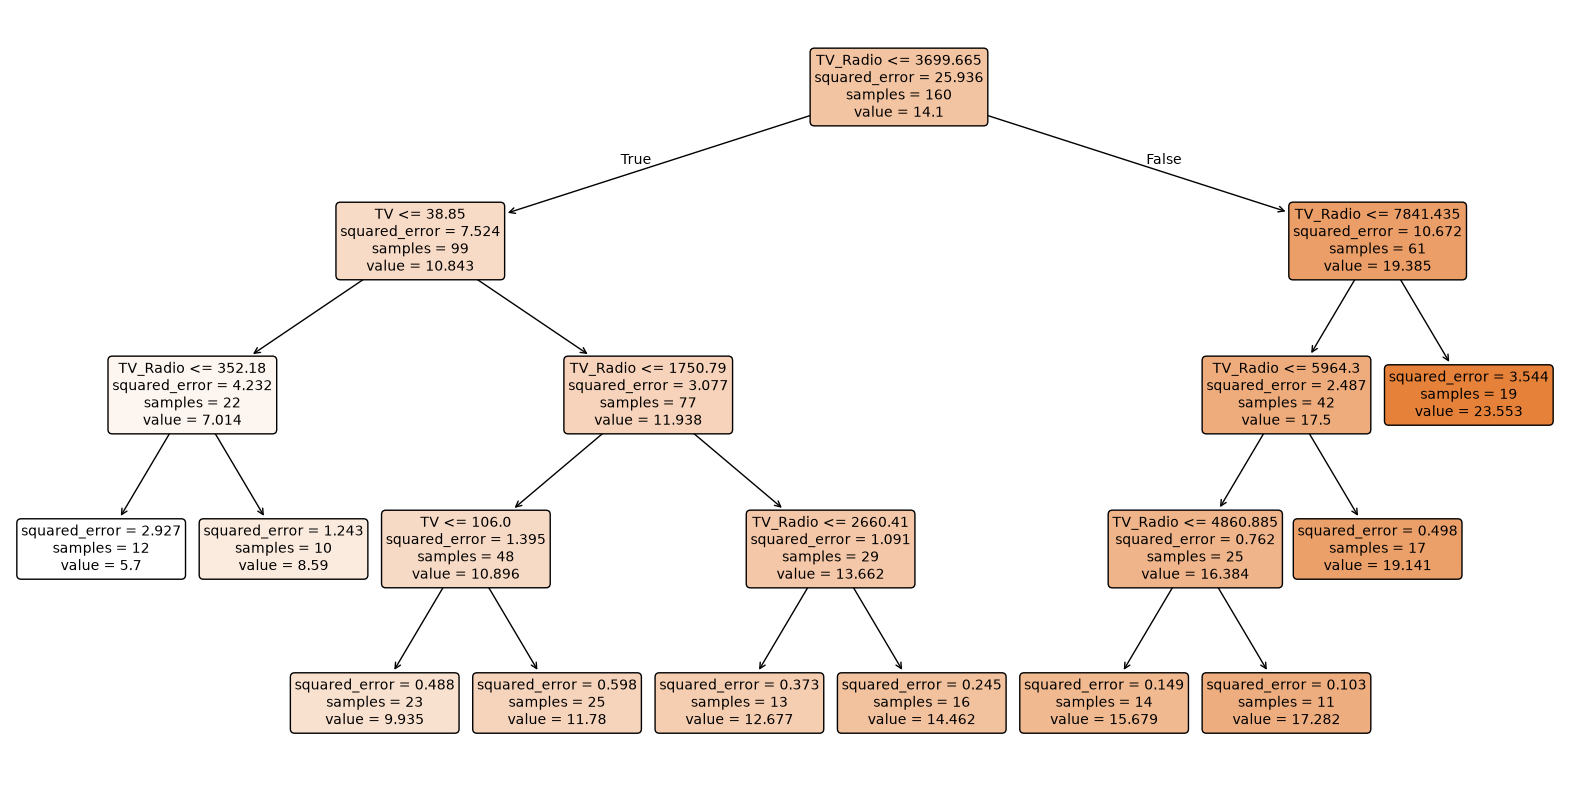

In [17]:


plt.figure(figsize=(12, 5))

sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.8)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Comparison of actual and predicted sales")


plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True
)
plt.show()

### SVM

In [27]:
# Import SVR for the model
from sklearn.svm import SVR

model = SVR()
model.fit(X_train, y_train)

y_pred_svm = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_svm)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svm))
r2 = r2_score(y_test, y_pred_svm)

print("SVM - Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

results['SVM'] = {"MAE": mae, "RMSE": rmse, "R²": r2}




SVM - Model Performance:
Mean Absolute Error (MAE): 1.51
Root Mean Squared Error (RMSE): 2.00
R² Score: 0.87


Text(0.5, 1.0, 'Comparison of actual and predicted sales')

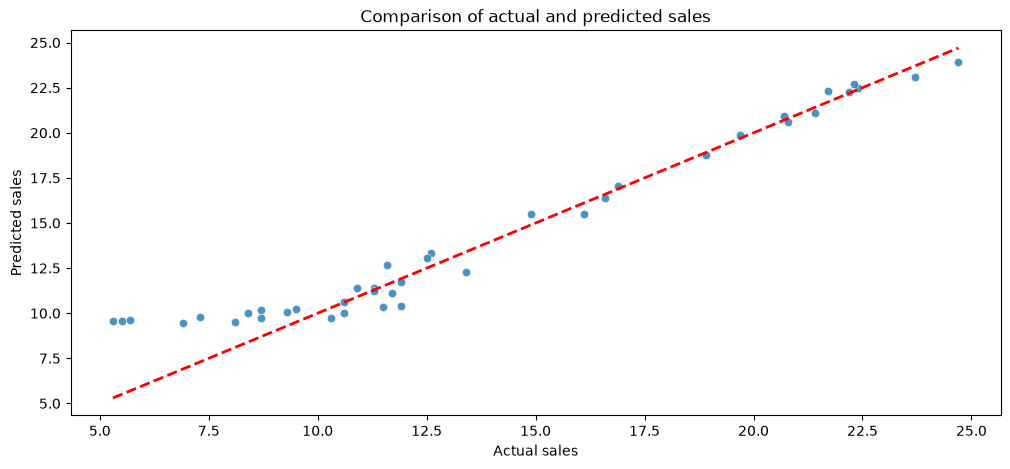

In [19]:


plt.figure(figsize=(12, 5))

sns.scatterplot(x=y_test, y=y_pred_svm, alpha=0.8)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Comparison of actual and predicted sales")

### Random Forest

In [20]:
# Import RandomForestRegressor for the model
from sklearn.ensemble import RandomForestRegressor

# Features (TV + Radio + Newspaper)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest - Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

results['Random Forest'] = {"MAE": mae, "RMSE": rmse, "R²": r2}





Random Forest - Model Performance:
Mean Absolute Error (MAE): 0.62
Root Mean Squared Error (RMSE): 0.77
R² Score: 0.98


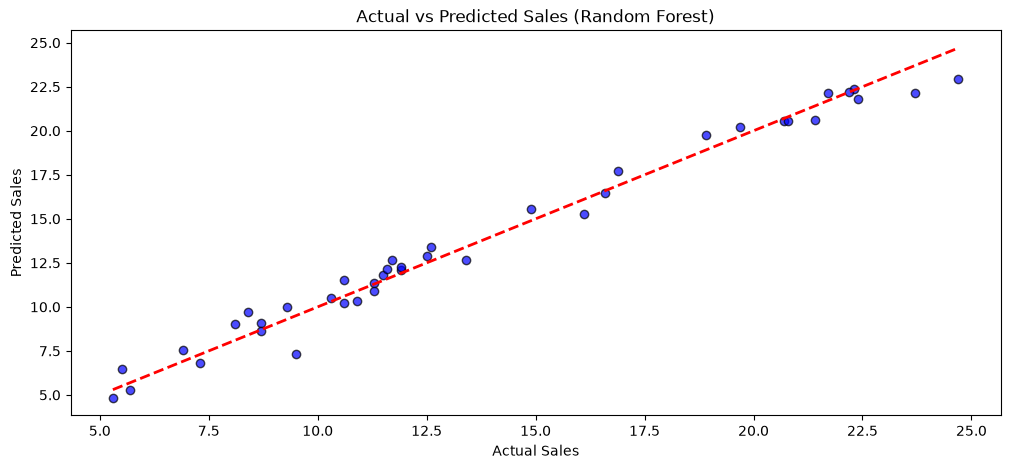

In [21]:


# Scatter plot of Actual vs Predicted
plt.figure(figsize=(12,5))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color="blue", edgecolor="k")

# Add reference line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.show()

### Models evaluation

In [22]:


results_df = pd.DataFrame(results).T.sort_values("R²", ascending=False)
print(results_df)



                        MAE      RMSE        R²
Random Forest      0.620325  0.768717  0.981278
Linear Regression  0.671804  0.902458  0.974197
Decision Tree      0.958376  1.211522  0.953498
SVM                0.956762  1.435824  0.934685


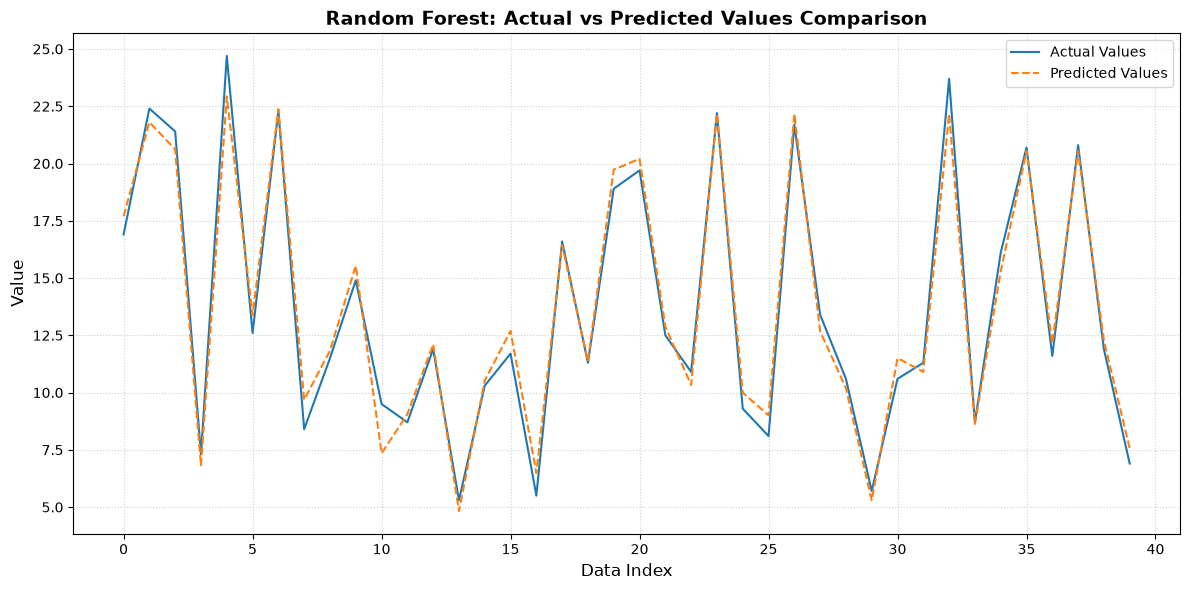

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(y_test, y_pred, model_name="Model"):
    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(len(y_test)), y_test, label='Actual Values', linewidth=1.5)
    plt.plot(np.arange(len(y_test)), y_pred, label='Predicted Values', linewidth=1.5, linestyle='--')
    plt.title(f'{model_name}: Actual vs Predicted Values Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Data Index', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    print()

plot_actual_vs_predicted(y_test, y_pred_rf, model_name="Random Forest")

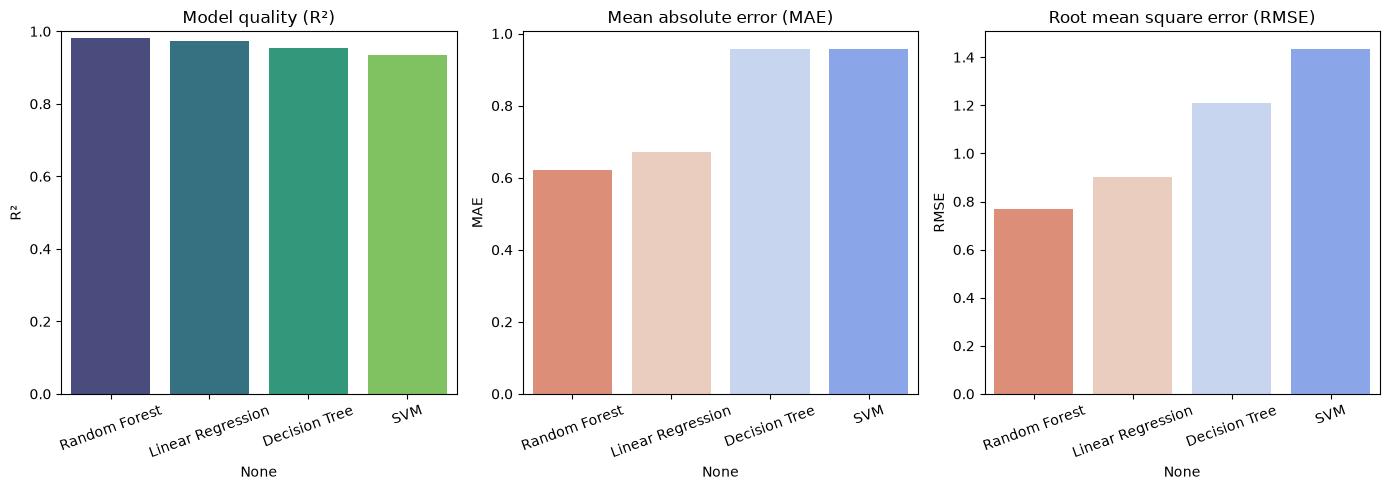

In [24]:


plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.barplot(x=results_df.index, y=results_df["R²"], palette="viridis")
plt.title("Model quality (R²)")
plt.ylim(0, 1)
plt.ylabel("R²")
plt.xticks(rotation=20)

plt.subplot(1, 3, 2)
sns.barplot(x=results_df.index, y=results_df["MAE"], palette="coolwarm_r")
plt.title("Mean absolute error (MAE)")
plt.ylabel("MAE")
plt.xticks(rotation=20)

plt.subplot(1, 3, 3)
sns.barplot(x=results_df.index, y=results_df["RMSE"], palette="coolwarm_r")
plt.title("Root mean square error (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

# Define a fixed total budget and different allocation strategies
total_budget = 200

# Scenarios: Different distributions of the same total budget across channels
# Format: [TV, Radio, Newspaper]
scenarios_data = {
    "TV Focused": [150, 30, 20],
    "Balanced": [66, 67, 67],
    "Radio Focused": [30, 150, 20],
    "Newspaper Focused": [30, 30, 140]
}

# Create a DataFrame for the new data points
new_data = pd.DataFrame(scenarios_data).T
new_data.columns = ['TV', 'Radio', 'Newspaper']

# Make predictions using your trained model (rf_model or lin_model)
predicted_sales = rf_model.predict(new_data)

# Combine scenarios with predictions for clear output
results = pd.DataFrame({
    'Strategy': new_data.index,
    'TV Spend': new_data['TV'],
    'Radio Spend': new_data['Radio'],
    'Newspaper Spend': new_data['Newspaper'],
    'Predicted Sales': predicted_sales.round(2)
})

print("Impact of Budget Allocation on Sales (Total Budget: 200)")
print(results.to_string(index=False))

Impact of Budget Allocation on Sales (Total Budget: 200)
         Strategy  TV Spend  Radio Spend  Newspaper Spend  Predicted Sales
       TV Focused       150           30               20            16.68
         Balanced        66           67               67            13.98
    Radio Focused        30          150               20             9.74
Newspaper Focused        30           30              140             9.01


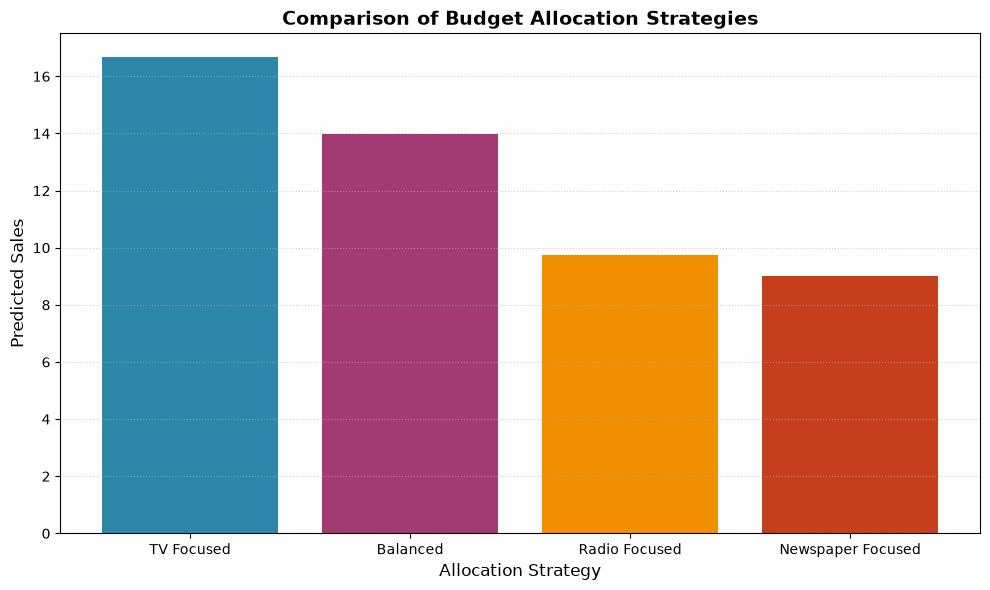

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(results['Strategy'], results['Predicted Sales'], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])

plt.title('Comparison of Budget Allocation Strategies', fontsize=14, fontweight='bold')
plt.xlabel('Allocation Strategy', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
